In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("C:/Users/user/Documents/EBAC/dados/winequality-red.csv", delimiter=',')

df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


In [4]:
# 1 - Realize a primeira etapa de pré processamento dos dados.

In [5]:
# A) Verifique os tipos de dados.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [7]:
# B) Verifique os dados faltantes, se houver dados faltantes faça a substituição ou remoção justificando sua escolha.

In [8]:
df.isnull().values.any() 

False

In [9]:
# Não há dados faltantes

In [10]:
# 2 - Realize a segunda e terceita etapa de pré processamento dos dados.

In [11]:
# A) Utilize a função describe para identificarmos outliers e verificarmos a distribuição dos dados.

In [12]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [13]:
# B) Verifique o balanceamento da váriavel Target.

In [14]:
# 1. Contagem de Valores com Pandas
quality_counts = df['quality'].value_counts().sort_index()
print("Contagem de valores da variável 'quality':")
print(quality_counts)

Contagem de valores da variável 'quality':
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


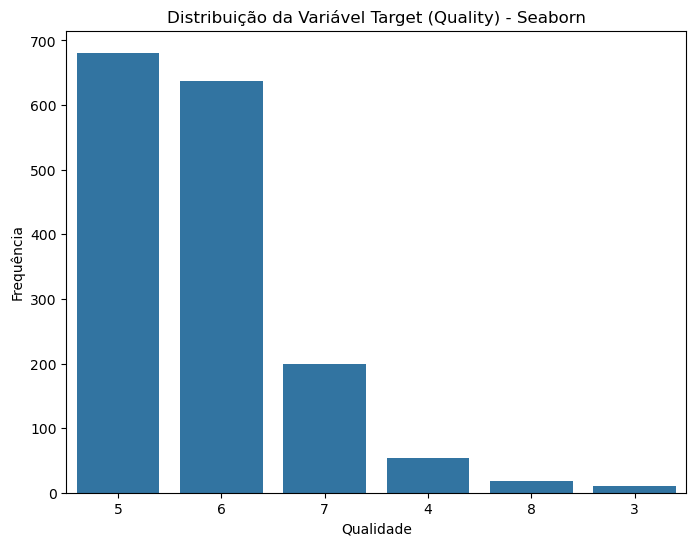

In [15]:
# 3. Visualização com Seaborn
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='quality', order=df['quality'].value_counts().index)
plt.title('Distribuição da Variável Target (Quality) - Seaborn')
plt.xlabel('Qualidade')
plt.ylabel('Frequência')
plt.show()

In [16]:
# C)  Plote o gráfico ou a tabela e indique as variáveis que te parecem mais "fortes" na correlação para nosso modelo.

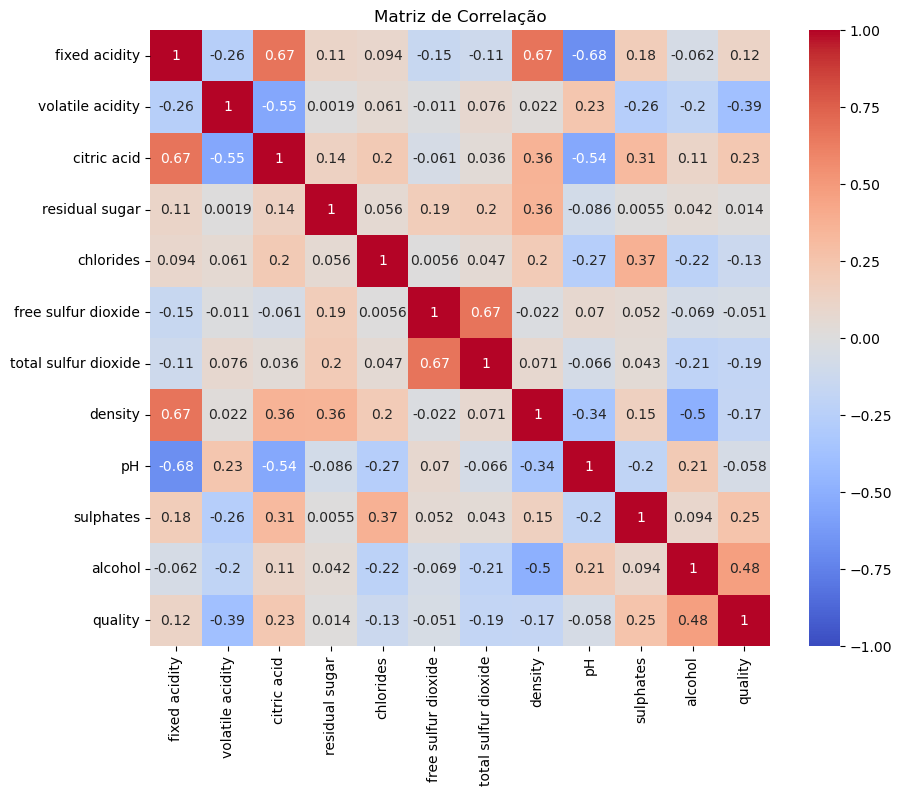

In [17]:
correlation_matrix = df.corr()

# plotando a matriz de correlação usando seaborn
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlação')
plt.show()

In [18]:
# As variáveis que aparentam serem as mais 'fortes' em relação a qualidade do vinho são: 'fixed acidity', 'citric acid', 'sulphates' e 'alcohol'

In [19]:
# D) Crie um novo dataframe apenas com as váriaveis que parecem ter maior correlação com a target. (Negativa ou positiva)

In [20]:
colunas_selecionadas = ['fixed acidity', 'citric acid', 'sulphates', 'alcohol', 'quality']

# Cria um novo DataFrame contendo apenas as colunas selecionadas
df_corr = df[colunas_selecionadas].copy()

df_corr.head(10)

,fixed acidity,citric acid,sulphates,alcohol,quality
0,7.4,0.00,0.56,9.4,5
1,7.8,0.00,0.68,9.8,5
2,7.8,0.04,0.65,9.8,5
3,11.2,0.56,0.58,9.8,6
4,7.4,0.00,0.56,9.4,5
5,7.4,0.00,0.56,9.4,5
6,7.9,0.06,0.46,9.4,5
7,7.3,0.00,0.47,10.0,7
8,7.8,0.02,0.57,9.5,7
9,7.5,0.36,0.80,10.5,5


In [21]:
# 3 - Preparação Final dos Dados

In [22]:
# A) Separe a base em X(Features) e Y(Target)

In [23]:
# Separando em X (Variáveis de entrada) e Y (Variável de saída)

X = df_corr.drop('quality', axis=1) # X contém todas as colunas, exceto 'quality'
Y = df_corr['quality'] # Y contém apenas a coluna 'quality'

In [24]:
# B) Separe a base em treino e teste.

In [25]:
# Separar em base de treino e teste (usando 80% para treino e 20% para teste)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [26]:
# 4 - Modelagem

In [27]:
# A) Inicie e treine o modelo de Random Forest

In [28]:
# Iniciando o modelo random forest
rf_model = RandomForestClassifier(random_state=42)

In [29]:
# Treinando o modelo
rf_model.fit(X_train, Y_train)

RandomForestClassifier(random_state=42)

In [30]:
# B) Aplique a base de teste o modelo.

In [31]:
# Fazendo previsões no conjunto de teste
Y_pred = rf_model.predict(X_test)

In [32]:
# 5 - Avaliação

In [33]:
# A) Avalie as principais métricas da Claissificação e traga insights acerca do resultado, interprete os valores achados.

In [34]:
# Avaliando o modelo
accuracy = accuracy_score(Y_test, Y_pred)
report = classification_report(Y_test, Y_pred)
conf_matrix = confusion_matrix(Y_test, Y_pred)

print(f"Acurácia: {accuracy:.2f}")
print("Relatório de Classificação:\n", report)
print("Matriz de Confusão:\n", conf_matrix)

Acurácia: 0.60
Relatório de Classificação:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.66      0.73      0.69       130
           6       0.56      0.56      0.56       132
           7       0.55      0.55      0.55        42
           8       0.00      0.00      0.00         5

    accuracy                           0.60       320
   macro avg       0.29      0.31      0.30       320
weighted avg       0.57      0.60      0.58       320

Matriz de Confusão:
 [[ 0  0  1  0  0  0]
 [ 0  0  6  4  0  0]
 [ 0  0 95 34  1  0]
 [ 0  1 43 74 14  0]
 [ 0  0  0 19 23  0]
 [ 0  0  0  1  4  0]]


D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [35]:
# # para as classes preditas (vinhos de qualidade 5, 6 e 7) !!

# precisão: tivemos uma precisao de 66% para o vinho de qualidade 5 e uma precisao de 56% e 55% para as classses 6 e 7 e, estas sao as taxas das previsoes
# positivas corretas

# Recall: respectivamente tivemos um recall de 73%, 56% e 55 e, esta é a taxa dos reia positivos previstos corretamente

# f1-score: O F1 Score é a média harmônica da Precisão e do Recall, e os valores foram respectivamente 0.69, 0,56 e 0,55

In [36]:
# B) Você nota que o modelo teve dificuldade para prever alguma classe? Se sim, acredita que tenha relação com o alanceamento dos dados? Explique.

In [37]:
# Sim, notei que nao tivemos previsoes para os vinhos de qualidade 3, 4 e 8. creio que devido o baixo numero de vinhos nestas qualidades, o modelo
# nao separou adequadamente os dados para contar com treino e teste nestas ditas qualidades de vinho

In [38]:
# 5 - Melhorando os Hyperparametros

In [39]:
# A) Defina o Grid de parametros que você quer testar

In [40]:
# Definir o espaço de busca dos hiperparâmetros
param_grid = {
	'n_estimators': [50, 100, 200],
	'max_depth': [None, 10, 20, 30],
	'min_samples_split': [2, 5, 10],
	'max_features': ['sqrt', 'log2', None]
}

In [41]:
# Configurando o randomized Search
random_search = RandomizedSearchCV(estimator=rf_model,
					param_distributions=param_grid,
					n_iter=100, cv=5, n_jobs=-1, verbose=2, random_state=42, scoring='accuracy')

In [ ]:
# B) Inicie e Treine um novo modelo utilizando o random search.

In [42]:
# Executando o Randomized Search
random_search.fit(X_train, Y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20, 30],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [50, 100, 200]},
                   random_state=42, scoring='accuracy', verbose=2)

In [ ]:
# C) Avalie os resultados do modelo.

In [44]:
# Obtendo os melhores hiperparâmetros através do método randomico
best_params = random_search.best_params_
print(f"Melhores Hiperparâmetros: {best_params}")

Melhores Hiperparâmetros: {'n_estimators': 100, 'min_samples_split': 2, 'max_features': 'log2', 'max_depth': None}


In [45]:
# Treinando o modelo com os melhores hiperparâmetros encontrados acima
best_rf_model = random_search.best_estimator_
best_rf_model.fit(X_train, Y_train)

RandomForestClassifier(max_features='log2', random_state=42)

In [46]:
Y_pred = best_rf_model.predict(X_test)

In [47]:
# Avaliando o modelo
accuracy = accuracy_score(Y_test, Y_pred)
report = classification_report(Y_test, Y_pred)
conf_matrix = confusion_matrix(Y_test, Y_pred)

print(f"Acurácia: {accuracy:.2f}")
print("Relatório de Classificação:\n", report)
print("Matriz de Confusão:\n", conf_matrix)

Acurácia: 0.60
Relatório de Classificação:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.66      0.73      0.69       130
           6       0.56      0.56      0.56       132
           7       0.55      0.55      0.55        42
           8       0.00      0.00      0.00         5

    accuracy                           0.60       320
   macro avg       0.29      0.31      0.30       320
weighted avg       0.57      0.60      0.58       320

Matriz de Confusão:
 [[ 0  0  1  0  0  0]
 [ 0  0  6  4  0  0]
 [ 0  0 95 34  1  0]
 [ 0  1 43 74 14  0]
 [ 0  0  0 19 23  0]
 [ 0  0  0  1  4  0]]


D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# D) Você identificou melhorias no modelo após aplicar o random search? Justifique.


# ps. Essa parte da atividade demorará um pouco para rodar!

In [ ]:
# O modelo nao apresentou melhorias, as estatisticas sao as mesmas 

In [ ]:
# 6 - Chegando a perfeição

# Baseado em tudo que você já aprendeu até agora, quais outras técnicas você acredita que poderiam ser aplicadas ao modelo para melhorar ainda mais 
# suas previsões?

In [ ]:
#  Regressão Linear:

# Porquê: É um método fundamental que modela a relação entre uma variável dependente (o que você quer prever) e uma ou mais variáveis independentes (os fatores que influenciam a previsão) assumindo uma relação linear entre elas. É simples, rápida e fácil de interpretar, mostrando diretamente como cada variável independente afeta a previsão.

# Support Vector Machines (SVMs):

# Porquê: Originalmente desenvolvido para classificação, o SVM também pode ser adaptado para tarefas de regressão (SVR - Support Vector Regression). Ele busca encontrar o melhor hiperplano que representa a relação entre as variáveis, tentando manter o máximo de pontos dentro de uma margem de erro definida. É eficaz em espaços de alta dimensão e pode lidar com relações não lineares através do uso de "kernels".